# 1. Install Libraries

In [1]:
pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


# 2. Import Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 3. Load Dataset

In [18]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print(df.head())
print(df.info())
print(df.describe())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

# 4. Data Cleaning

In [19]:
# Check missing values
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


# 5. Select Features

In [20]:
X = df[['Hours_Studied']]   # feature
y = df['Exam_Score']        # target

# 6. Data Visualization

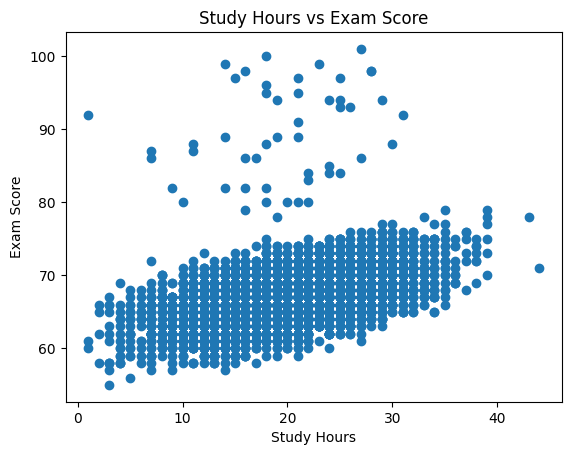

In [21]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

# 7. Split Dataset (Training & Testing)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Linear Regression Model

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 9.  Predictions are 

In [24]:
y_pred = model.predict(X_test)

print("Predicted Scores:", y_pred)

Predicted Scores: [70.4286184  65.23844964 69.27524757 ... 67.2568486  64.95010693
 69.27524757]


# 10. Model Evaluation

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 2.5292420695261244
Mean Squared Error: 12.351733799445533
R2 Score: 0.20513060832466712


# 11. Visualization of Regression Line

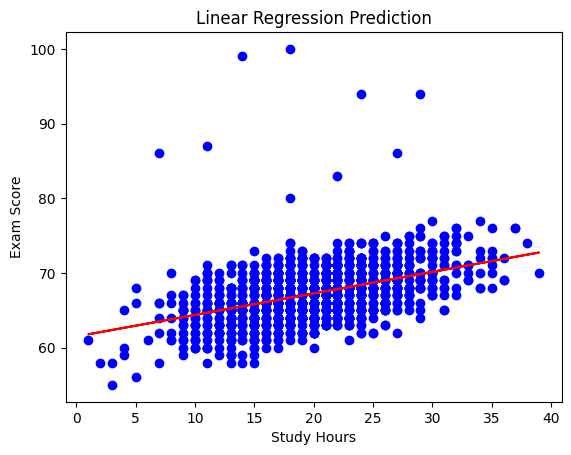

In [26]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression Prediction")

plt.show()

# 12.  Polynomial Regression

In [27]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)

y_pred_poly = poly_model.predict(X_test_p)

print("Polynomial R2 Score:", r2_score(y_test_p, y_pred_poly))

Polynomial R2 Score: 0.2050784559067499


# 13. Comparison Linear vs Polynomial

In [30]:
print("Linear R2:", r2)
print("Polynomial R2:", r2_score(y_test_p, y_pred_poly))

Linear R2: 0.20513060832466712
Polynomial R2: 0.2050784559067499
